# 🛒 E-Commerce Dashboard — Verification & EDA
### `table_shopify_sales_analysis` | 60,000 rows | 17 columns

This notebook independently verifies every KPI and chart value shown in the dashboard.  
Each cell is a standalone check. Run top-to-bottom for a full audit.

---
**Table:** `table_shopify_sales_analysis`  
**Columns:** order_id, order_date, customer_id, product_id, product_category, product_price,  
discount_percent, quantity, customer_country, traffic_source, payment_method, shipping_cost,  
rating, is_returned, discounted_price, revenue, profit


## 📦 Cell 1 — Imports & Data Load

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#060818',
    'axes.facecolor':   '#0d1130',
    'axes.edgecolor':   '#ffffff1a', # White with ~10% alpha (1a in hex)
    'axes.labelcolor':  '#e8eaf6',
    'xtick.color':      '#9094b1',
    'ytick.color':      '#9094b1',
    'text.color':       '#e8eaf6',
    'grid.color':       '#ffffff0f', # White with ~6% alpha (0f in hex)
    'grid.linestyle':   '--',
    'font.family':      'sans-serif',
    'figure.dpi':       110,
})
PALETTE = ['#6c63ff','#10d9a0','#f4637a','#f5c542','#38b2f8','#a78bfa','#fb923c','#4ade80','#f472b6','#60a5fa']

# ── Load ───────────────────────────────────────────────────────────────────
df = pd.read_csv('table_shopify_sales_analysis.csv', parse_dates=['order_date'])

print("✅ Data loaded successfully")
print(f"   Shape       : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Date range  : {df['order_date'].min().date()} → {df['order_date'].max().date()}")
print(f"   Columns     : {list(df.columns)}")
df.head(3)


✅ Data loaded successfully
   Shape       : 60,000 rows × 17 columns
   Date range  : 2023-01-01 → 2025-06-18
   Columns     : ['order_id', 'order_date', 'customer_id', 'product_id', 'product_category', 'product_price', 'discount_percent', 'quantity', 'customer_country', 'traffic_source', 'payment_method', 'shipping_cost', 'rating', 'is_returned', 'discounted_price', 'revenue', 'profit']


,order_id,order_date,customer_id,product_id,product_category,product_price,discount_percent,quantity,customer_country,traffic_source,payment_method,shipping_cost,rating,is_returned,discounted_price,revenue,profit
0,1,2023-04-13,14958,7824,Accessories,143.39,40,1,USA,Paid Ads,Credit Card,21.08,2.0,0,86.03,86.03,64.95
1,2,2024-03-11,26825,5557,Sports,746.49,15,4,UAE,Email,PayPal,5.48,3.7,0,634.52,2538.08,2532.60
2,3,2025-05-10,37450,2225,Electronics,641.06,5,5,Canada,Paid Ads,Apple Pay,11.27,3.2,0,609.01,3045.05,3033.78


## 🔍 Cell 2 — Data Types & Null Check

In [5]:
print("─" * 55)
print(f"{'Column':<22} {'Dtype':<12} {'Nulls':>6}  {'Unique':>8}")
print("─" * 55)
for col in df.columns:
    print(f"  {col:<20} {str(df[col].dtype):<12} {df[col].isnull().sum():>6}  {df[col].nunique():>8}")
print("─" * 55)
print(f"\nTotal missing values : {df.isnull().sum().sum()}")
print(f"Duplicate order_ids  : {df['order_id'].duplicated().sum()}")


───────────────────────────────────────────────────────
Column                 Dtype         Nulls    Unique
───────────────────────────────────────────────────────
  order_id             int64             0     60000
  order_date           datetime64[ns]      0       900
  customer_id          int64             0     31154
  product_id           int64             0      6998
  product_category     object            0         7
  product_price        float64           0     42043
  discount_percent     int64             0         8
  quantity             int64             0         5
  customer_country     object            0         7
  traffic_source       object            0         5
  payment_method       object            0         5
  shipping_cost        float64           0      2301
  rating               float64           0        41
  is_returned          int64             0         2
  discounted_price     float64           0     40228
  revenue              float64        

## 📊 Cell 3 — Descriptive Statistics

In [6]:
num_cols = ['product_price','discount_percent','quantity','shipping_cost',
            'rating','discounted_price','revenue','profit']
desc = df[num_cols].describe().T
desc['cv%'] = (desc['std'] / desc['mean'] * 100).round(1)
desc = desc.round(3)
print(desc.to_string())


                    count     mean      std    min      25%      50%       75%      max   cv%
product_price     60000.0  403.427  230.045   5.01  203.160  403.855   603.135   799.99  57.0
discount_percent  60000.0   18.152   12.528   0.00    5.000   20.000    30.000    40.00  69.0
quantity          60000.0    3.010    1.415   1.00    2.000    3.000     4.000     5.00  47.0
shipping_cost     60000.0   13.522    6.628   2.00    7.760   13.580    19.230    25.00  49.0
rating            60000.0    3.002    1.152   1.00    2.000    3.000     4.000     5.00  38.4
discounted_price  60000.0  330.220  197.115   3.08  161.958  322.560   482.242   799.90  59.7
revenue           60000.0  994.099  806.446   3.08  355.620  760.470  1462.450  3999.50  81.1
profit            60000.0  980.577  806.508 -20.49  341.925  747.275  1449.808  3989.95  82.2


## ✅ Cell 4 — KPI 1: Total Revenue

In [7]:
total_revenue = df['revenue'].sum()
print(f"Total Revenue = ${total_revenue:,.2f}")
if total_revenue >= 1e6:
    print(f"Formatted     = ${total_revenue/1e6:.2f}M  ← dashboard should show this")
elif total_revenue >= 1e3:
    print(f"Formatted     = ${total_revenue/1e3:.1f}K")


Total Revenue = $59,645,935.58
Formatted     = $59.65M  ← dashboard should show this


## ✅ Cell 5 — KPI 2: Total Quantity Sold

In [8]:
total_qty = df['quantity'].sum()
print(f"Total Quantity = {total_qty:,}")
if total_qty >= 1e3:
    print(f"Formatted      = {total_qty/1e3:.1f}K  ← dashboard should show this")


Total Quantity = 180,574
Formatted      = 180.6K  ← dashboard should show this


## ✅ Cell 6 — KPI 3: Return Rate (%)

In [28]:
total_orders = len(df)
total_returned = df['is_returned'].sum()
return_rate = total_returned / total_orders * 100
print(f"Total Orders   = {total_orders:,}")
print(f"Total Returned = {int(total_returned):,}")
print(f"Return Rate    = {return_rate:.2f}%  ← dashboard should show this")


Total Orders   = 60,000
Total Returned = 8,887
Return Rate    = 14.81%  ← dashboard should show this


## ✅ Cell 7 — KPI 4: Lost Revenue (from returns)

In [10]:
lost_revenue = df[df['is_returned'] == 1]['revenue'].sum()
print(f"Lost Revenue = ${lost_revenue:,.2f}")
if lost_revenue >= 1e6:
    print(f"Formatted    = ${lost_revenue/1e6:.2f}M  ← dashboard should show this")
elif lost_revenue >= 1e3:
    print(f"Formatted    = ${lost_revenue/1e3:.1f}K")


Lost Revenue = $8,782,562.98
Formatted    = $8.78M  ← dashboard should show this


## ✅ Cell 8 — KPI 5: Average Rating

In [11]:
avg_rating = df['rating'].mean()
print(f"Avg Rating = {avg_rating:.2f} ★  ← dashboard should show this")
print(f"Min: {df['rating'].min()}, Max: {df['rating'].max()}")
print(f"Rating distribution:\n{df['rating'].value_counts().sort_index()}")


Avg Rating = 3.00 ★  ← dashboard should show this
Min: 1.0, Max: 5.0
Rating distribution:
rating
1.0     738
1.1    1457
1.2    1516
1.3    1431
1.4    1477
1.5    1492
1.6    1508
1.7    1533
1.8    1511
1.9    1468
2.0    1516
2.1    1512
2.2    1455
2.3    1484
2.4    1523
2.5    1517
2.6    1492
2.7    1536
2.8    1530
2.9    1553
3.0    1491
3.1    1556
3.2    1497
3.3    1481
3.4    1515
3.5    1519
3.6    1475
3.7    1525
3.8    1470
3.9    1479
4.0    1467
4.1    1555
4.2    1511
4.3    1498
4.4    1467
4.5    1529
4.6    1474
4.7    1478
4.8    1504
4.9    1517
5.0     743
Name: count, dtype: int64


## ✅ Cell 9 — KPI 6: Total Orders

In [12]:
total_orders = len(df)
print(f"Total Orders = {total_orders:,}")
if total_orders >= 1e3:
    print(f"Formatted    = {total_orders/1e3:.1f}K  ← dashboard should show this")


Total Orders = 60,000
Formatted    = 60.0K  ← dashboard should show this


## ✅ Cell 10 — KPI 7: Total Customers (Distinct)

In [13]:
total_customers = df['customer_id'].nunique()
print(f"Total Customers (distinct) = {total_customers:,}  ← dashboard should show this")
print(f"Total rows                 = {len(df):,}")
print(f"Avg orders per customer    = {len(df)/total_customers:.2f}")


Total Customers (distinct) = 31,154  ← dashboard should show this
Total rows                 = 60,000
Avg orders per customer    = 1.93


## ✅ Cell 11 — KPI 8: Total Profit

In [14]:
total_profit = df['profit'].sum()
profit_margin = total_profit / df['revenue'].sum() * 100
print(f"Total Profit   = ${total_profit:,.2f}")
if total_profit >= 1e6:
    print(f"Formatted      = ${total_profit/1e6:.2f}M  ← dashboard should show this")
print(f"Profit Margin  = {profit_margin:.2f}%")
print(f"Negative Profit Rows: {(df['profit'] < 0).sum()}")


Total Profit   = $58,834,630.10
Formatted      = $58.83M  ← dashboard should show this
Profit Margin  = 98.64%
Negative Profit Rows: 230


## ✅ Cell 12 — KPI 9: Total Discount Value

In [15]:
df['discount_value'] = df['product_price'] - df['discounted_price']
total_discount = df['discount_value'].sum()
print(f"Total Discount Value = ${total_discount:,.2f}")
if total_discount >= 1e3:
    print(f"Formatted            = ${total_discount/1e3:.1f}K  ← dashboard should show this")
print(f"\nVerification check: product_price - discounted_price")
print(df[['product_price','discount_percent','discounted_price','discount_value']].head(5).to_string(index=False))


Total Discount Value = $4,392,411.34
Formatted            = $4392.4K  ← dashboard should show this

Verification check: product_price - discounted_price
 product_price  discount_percent  discounted_price  discount_value
        143.39                40             86.03           57.36
        746.49                15            634.52          111.97
        641.06                 5            609.01           32.05
        512.39                 0            512.39            0.00
        415.89                25            311.92          103.97


## ✅ Cell 13 — KPI 10: Avg Shipping Cost

In [16]:
avg_shipping = df['shipping_cost'].mean()
print(f"Avg Shipping Cost = ${avg_shipping:.2f}  ← dashboard should show this")
print(f"Min: ${df['shipping_cost'].min():.2f}, Max: ${df['shipping_cost'].max():.2f}")
print(f"Median: ${df['shipping_cost'].median():.2f}")


Avg Shipping Cost = $13.52  ← dashboard should show this
Min: $2.00, Max: $25.00
Median: $13.58


## 🧾 Cell 14 — Full KPI Audit Summary Table

In [17]:
def fmt_val(v):
    if abs(v) >= 1e6: return f'${v/1e6:.2f}M'
    if abs(v) >= 1e3: return f'${v/1e3:.1f}K'
    return f'${v:.2f}'

kpis = {
    'KPI': ['Total Revenue','Total Quantity','Return Rate','Lost Revenue','Avg Rating',
            'Total Orders','Total Customers','Total Profit','Total Discount Value','Avg Shipping Cost'],
    'Raw Value': [
        df['revenue'].sum(),
        df['quantity'].sum(),
        df['is_returned'].sum()/len(df)*100,
        df[df['is_returned']==1]['revenue'].sum(),
        df['rating'].mean(),
        len(df),
        df['customer_id'].nunique(),
        df['profit'].sum(),
        (df['product_price'] - df['discounted_price']).sum(),
        df['shipping_cost'].mean(),
    ],
    'Formatted': [
        fmt_val(df['revenue'].sum()),
        f"{df['quantity'].sum()/1e3:.1f}K",
        f"{df['is_returned'].sum()/len(df)*100:.2f}%",
        fmt_val(df[df['is_returned']==1]['revenue'].sum()),
        f"{df['rating'].mean():.2f} ★",
        f"{len(df)/1e3:.1f}K",
        f"{df['customer_id'].nunique():,}",
        fmt_val(df['profit'].sum()),
        fmt_val((df['product_price']-df['discounted_price']).sum()),
        f"${df['shipping_cost'].mean():.2f}",
    ]
}
audit_df = pd.DataFrame(kpis)
print(audit_df.to_string(index=False))


                 KPI    Raw Value Formatted
       Total Revenue 5.964594e+07   $59.65M
      Total Quantity 1.805740e+05    180.6K
         Return Rate 1.481167e+01    14.81%
        Lost Revenue 8.782563e+06    $8.78M
          Avg Rating 3.002440e+00    3.00 ★
        Total Orders 6.000000e+04     60.0K
     Total Customers 3.115400e+04    31,154
        Total Profit 5.883463e+07   $58.83M
Total Discount Value 4.392411e+06    $4.39M
   Avg Shipping Cost 1.352176e+01    $13.52


## 📈 Cell 15 — Chart 1: Revenue Trend Over Time

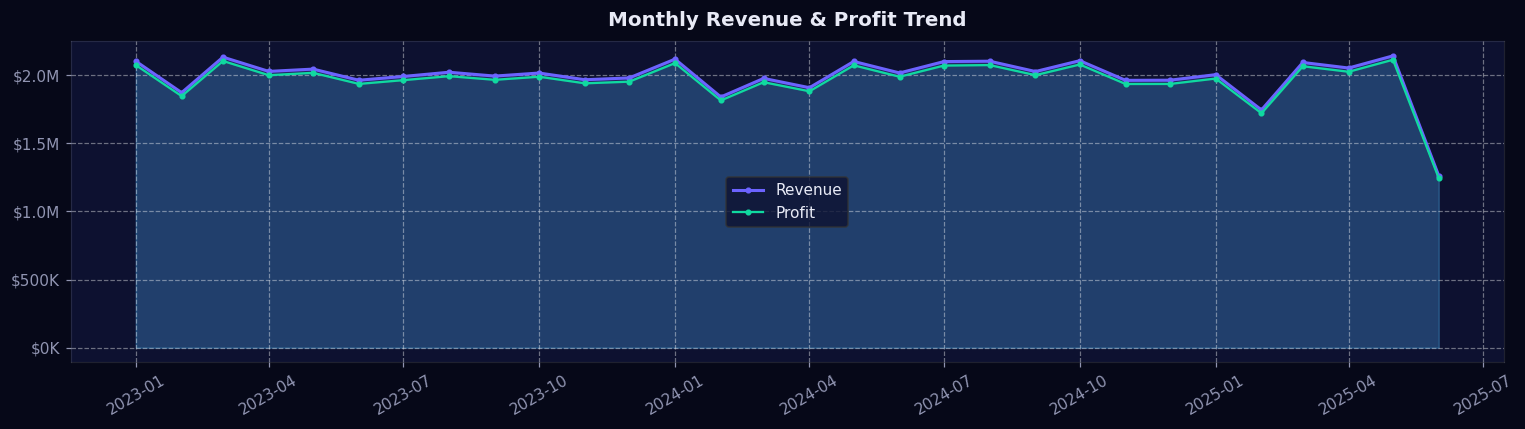

  month    Revenue     Profit   month_dt
2025-01 2004462.71 1976023.60 2025-01-01
2025-02 1745345.13 1721203.61 2025-02-01
2025-03 2093909.23 2066311.47 2025-03-01
2025-04 2053226.55 2025806.07 2025-04-01
2025-05 2142348.02 2114068.35 2025-05-01
2025-06 1262287.97 1245399.55 2025-06-01


In [18]:
df['month'] = df['order_date'].dt.to_period('M')
monthly = df.groupby('month').agg(Revenue=('revenue','sum'), Profit=('profit','sum')).reset_index()
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(monthly['month_dt'], monthly['Revenue'], alpha=0.25, color='#6c63ff')
ax.plot(monthly['month_dt'], monthly['Revenue'], color='#6c63ff', lw=2, marker='o', ms=3, label='Revenue')
ax.fill_between(monthly['month_dt'], monthly['Profit'], alpha=0.15, color='#10d9a0')
ax.plot(monthly['month_dt'], monthly['Profit'], color='#10d9a0', lw=1.5, marker='o', ms=3, label='Profit')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K' if x<1e6 else f'${x/1e6:.1f}M'))
ax.set_title('Monthly Revenue & Profit Trend', fontsize=13, fontweight='bold', pad=10)
ax.legend(facecolor='#0d1130', edgecolor='#333', fontsize=10)
ax.grid(True, alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('chart_01_revenue_trend.png', dpi=110, bbox_inches='tight', facecolor='#060818')
plt.show()
print(monthly.tail(6).to_string(index=False))


## 📊 Cell 16 — Chart 3: Revenue & Profit by Category

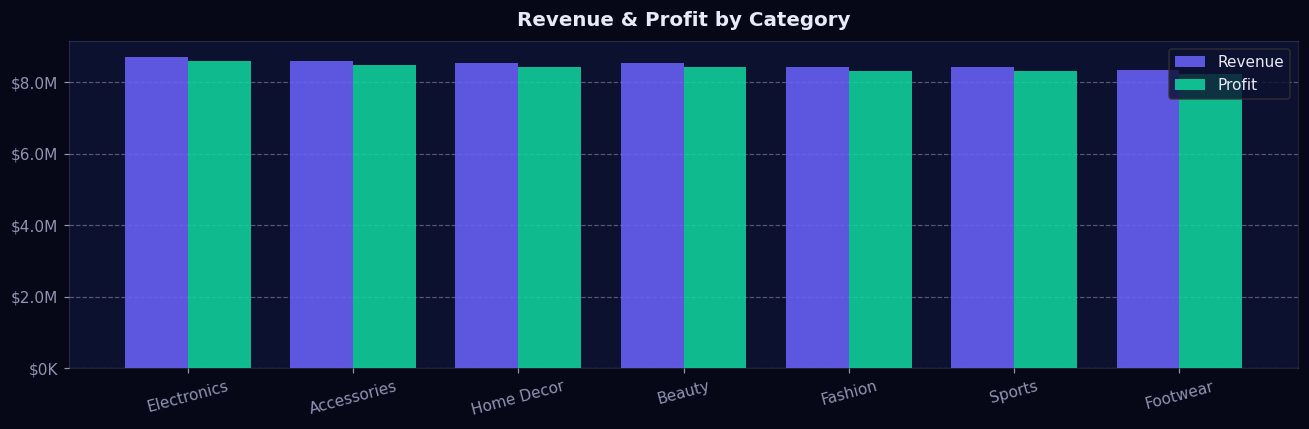

product_category    Revenue     Profit  Orders
     Electronics 8717301.49 8601068.01    8624
     Accessories 8609171.52 8492938.90    8617
      Home Decor 8545840.45 8428664.14    8600
          Beauty 8544881.95 8429076.60    8586
         Fashion 8445072.67 8327844.15    8594
          Sports 8434698.81 8319929.75    8522
        Footwear 8348968.69 8235108.55    8457


In [19]:
cat = df.groupby('product_category').agg(
    Revenue=('revenue','sum'), Profit=('profit','sum'), Orders=('order_id','count')
).sort_values('Revenue', ascending=False).reset_index()

x = np.arange(len(cat))
w = 0.38
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(x - w/2, cat['Revenue'], w, color='#6c63ff', alpha=0.85, label='Revenue', zorder=2)
ax1.bar(x + w/2, cat['Profit'],  w, color='#10d9a0', alpha=0.85, label='Profit',  zorder=2)
ax1.set_xticks(x); ax1.set_xticklabels(cat['product_category'], rotation=15)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e6:.1f}M' if v>=1e6 else f'${v/1e3:.0f}K'))
ax1.set_title('Revenue & Profit by Category', fontsize=13, fontweight='bold', pad=10)
ax1.legend(facecolor='#0d1130', edgecolor='#333', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('chart_03_category.png', dpi=110, bbox_inches='tight', facecolor='#060818')
plt.show()
print(cat.to_string(index=False))


## 🔄 Cell 17 — Chart 4: Return Analysis

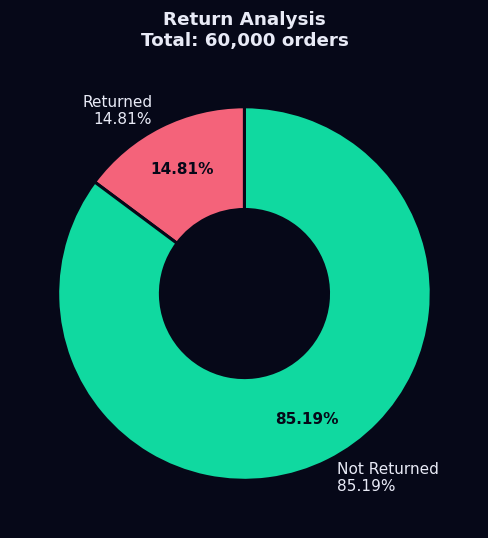

Returned     : 8,887 (14.81%)
Not Returned : 51,113 (85.19%)


In [20]:
ret_counts = df['is_returned'].value_counts()
returned  = int(ret_counts.get(1, 0))
not_ret   = int(ret_counts.get(0, 0))
total     = returned + not_ret
ret_rate  = returned / total * 100

fig, ax = plt.subplots(figsize=(6, 5))
wedges, texts, autotexts = ax.pie(
    [returned, not_ret],
    labels=[f'Returned\n{ret_rate:.2f}%', f'Not Returned\n{100-ret_rate:.2f}%'],
    colors=['#f4637a','#10d9a0'],
    autopct='%1.2f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='#060818', linewidth=2)
)
for t in autotexts: t.set_color('#060818'); t.set_fontweight('bold')
ax.set_title(f'Return Analysis\nTotal: {total:,} orders', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('chart_04_return.png', dpi=110, bbox_inches='tight', facecolor='#060818')
plt.show()
print(f"Returned     : {returned:,} ({ret_rate:.2f}%)")
print(f"Not Returned : {not_ret:,} ({100-ret_rate:.2f}%)")


## 🌍 Cell 18 — Chart 5: Revenue by Country

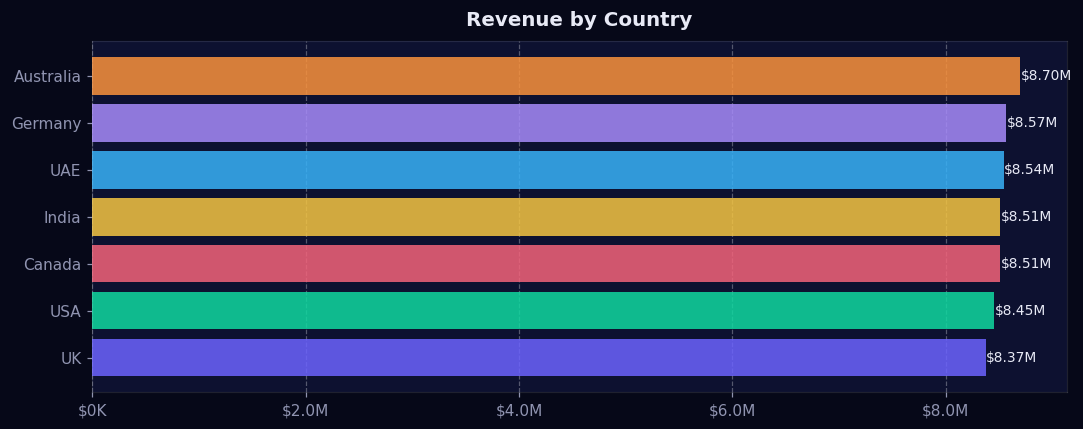

customer_country    Revenue  Orders
       Australia 8698940.71    8714
         Germany 8566995.25    8606
             UAE 8541233.92    8599
           India 8509138.00    8554
          Canada 8506629.46    8586
             USA 8450978.82    8469
              UK 8372019.42    8472


In [21]:
country = df.groupby('customer_country').agg(
    Revenue=('revenue','sum'), Orders=('order_id','count')
).sort_values('Revenue', ascending=True).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(country['customer_country'], country['Revenue'],
               color=PALETTE[:len(country)], alpha=0.85, zorder=2)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e6:.1f}M' if v>=1e6 else f'${v/1e3:.0f}K'))
for b in bars:
    ax.text(b.get_width()+5000, b.get_y()+b.get_height()/2,
            f'${b.get_width()/1e6:.2f}M' if b.get_width()>=1e6 else f'${b.get_width()/1e3:.0f}K',
            va='center', fontsize=9, color='#e8eaf6')
ax.set_title('Revenue by Country', fontsize=13, fontweight='bold', pad=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('chart_05_country.png', dpi=110, bbox_inches='tight', facecolor='#060818')
plt.show()
print(country.sort_values('Revenue', ascending=False).to_string(index=False))


## 📣 Cell 19 — Chart 6: Profit by Traffic Source

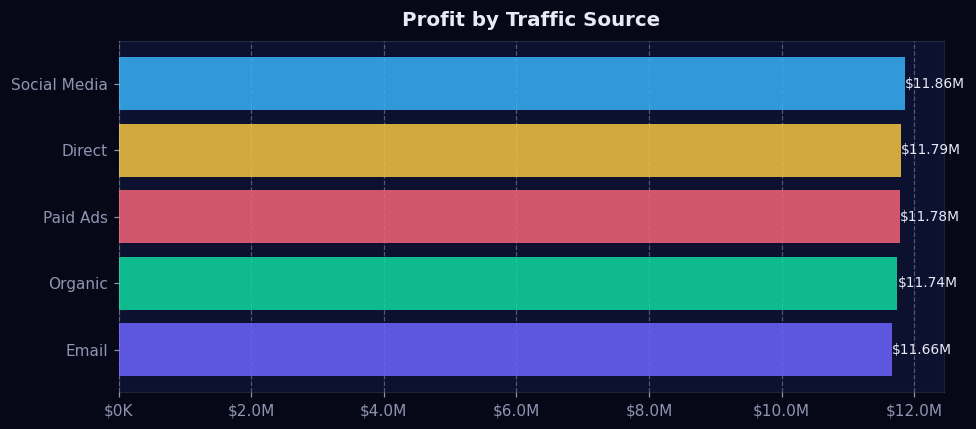

traffic_source      Profit  Orders
  Social Media 11860524.41   12024
        Direct 11791568.34   11961
      Paid Ads 11776228.62   12018
       Organic 11743990.64   12075
         Email 11662318.09   11922


In [22]:
traffic = df.groupby('traffic_source').agg(
    Profit=('profit','sum'), Orders=('order_id','count')
).sort_values('Profit', ascending=True).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(traffic['traffic_source'], traffic['Profit'],
               color=PALETTE[:len(traffic)], alpha=0.85, zorder=2)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e6:.1f}M' if v>=1e6 else f'${v/1e3:.0f}K'))
for b in bars:
    ax.text(b.get_width()+1000, b.get_y()+b.get_height()/2,
            f'${b.get_width()/1e6:.2f}M' if b.get_width()>=1e6 else f'${b.get_width()/1e3:.0f}K',
            va='center', fontsize=9, color='#e8eaf6')
ax.set_title('Profit by Traffic Source', fontsize=13, fontweight='bold', pad=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('chart_06_traffic.png', dpi=110, bbox_inches='tight', facecolor='#060818')
plt.show()
print(traffic.sort_values('Profit', ascending=False).to_string(index=False))


## 🏷️ Cell 20 — Chart 7: Discount % vs Avg Profit (Banded)

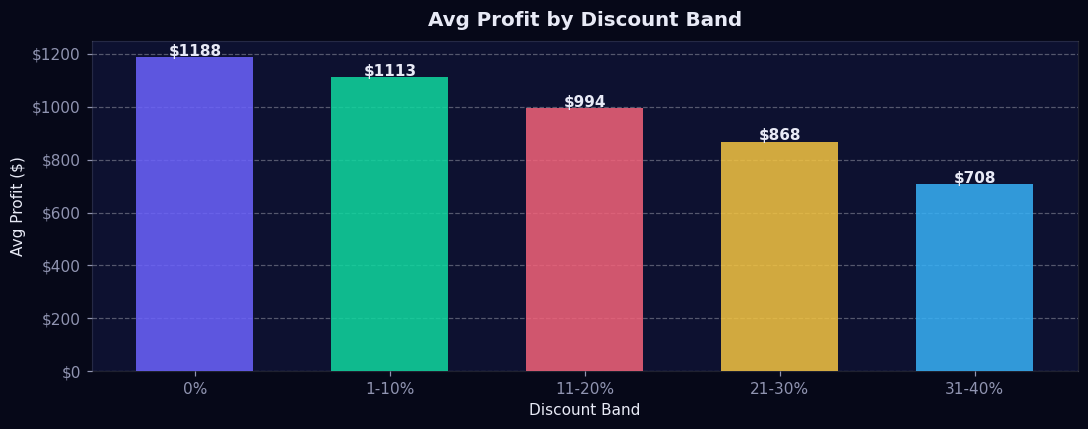

disc_band  Avg_Profit  Count
       0% 1188.381625   7567
    1-10% 1113.025759  14984
   11-20%  993.863950  14852
   21-30%  868.376706  15001
   31-40%  707.896527   7596


In [23]:
bins   = [-1, 0, 10, 20, 30, 40, 100]
labels = ['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41%+']
df['disc_band'] = pd.cut(df['discount_percent'], bins=bins, labels=labels)
disc_agg = df.groupby('disc_band', observed=True).agg(
    Avg_Profit=('profit','mean'), Count=('order_id','count')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(disc_agg['disc_band'].astype(str), disc_agg['Avg_Profit'],
              color=PALETTE[:len(disc_agg)], alpha=0.85, zorder=2, width=0.6)
for b, (_, row) in zip(bars, disc_agg.iterrows()):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5,
            f'${row["Avg_Profit"]:.0f}', ha='center', fontsize=10, color='#e8eaf6', fontweight='bold')
ax.set_xlabel('Discount Band'); ax.set_ylabel('Avg Profit ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.0f}'))
ax.set_title('Avg Profit by Discount Band', fontsize=13, fontweight='bold', pad=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('chart_07_discount_profit.png', dpi=110, bbox_inches='tight', facecolor='#060818')
plt.show()
print(disc_agg.to_string(index=False))


## ⭐ Cell 21 — Chart 8: Avg Rating vs Return Rate

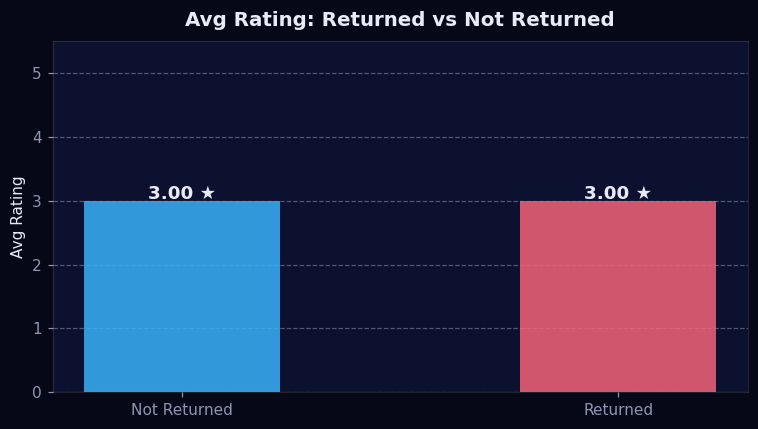

       label   rating
Not Returned 3.002694
    Returned 3.000979


In [24]:
rating_ret = df.groupby('is_returned')['rating'].mean().reset_index()
rating_ret['label'] = rating_ret['is_returned'].map({0: 'Not Returned', 1: 'Returned'})

fig, ax = plt.subplots(figsize=(7, 4))
colors_map = {0: '#38b2f8', 1: '#f4637a'}
bars = ax.bar(rating_ret['label'], rating_ret['rating'],
              color=[colors_map[i] for i in rating_ret['is_returned']],
              alpha=0.85, width=0.45, zorder=2)
for b, val in zip(bars, rating_ret['rating']):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.03,
            f'{val:.2f} ★', ha='center', fontsize=12, color='#e8eaf6', fontweight='bold')
ax.set_ylim(0, 5.5); ax.set_ylabel('Avg Rating')
ax.set_title('Avg Rating: Returned vs Not Returned', fontsize=13, fontweight='bold', pad=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('chart_08_rating_return.png', dpi=110, bbox_inches='tight', facecolor='#060818')
plt.show()
print(rating_ret[['label','rating']].to_string(index=False))


## 💳 Cell 22 — Chart 9: Payment Method Analysis

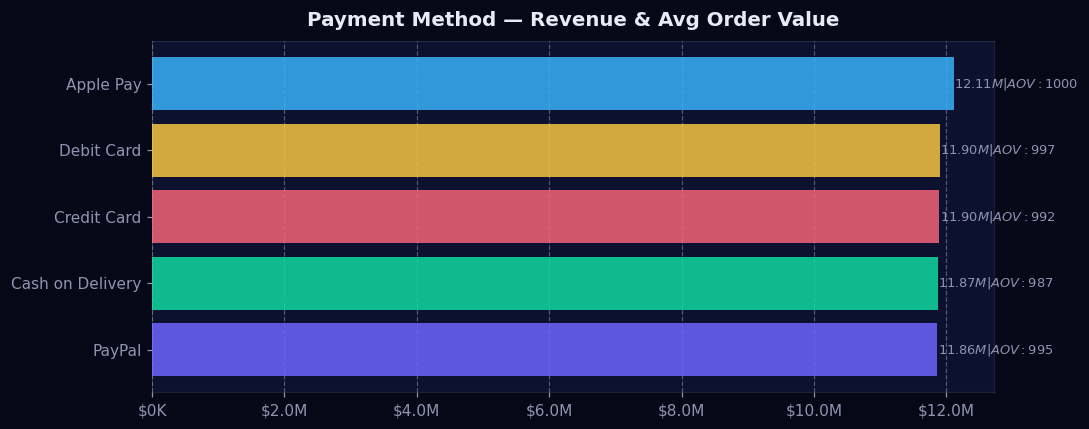

  payment_method     Revenue  Orders  Avg_Order_Value
       Apple Pay 12109957.21   12116       999.501255
      Debit Card 11903139.90   11936       997.246976
     Credit Card 11898249.20   11998       991.686048
Cash on Delivery 11870651.24   12032       986.590030
          PayPal 11863938.03   11918       995.463839


In [25]:
pay = df.groupby('payment_method').agg(
    Revenue=('revenue','sum'),
    Orders=('order_id','count')
).reset_index()
pay['Avg_Order_Value'] = pay['Revenue'] / pay['Orders']
pay = pay.sort_values('Revenue', ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(pay['payment_method'], pay['Revenue'],
               color=PALETTE[:len(pay)], alpha=0.85, zorder=2)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e6:.1f}M' if v>=1e6 else f'${v/1e3:.0f}K'))
for b, (_, row) in zip(bars, pay.iterrows()):
    ax.text(b.get_width()+10000, b.get_y()+b.get_height()/2,
            f'${b.get_width()/1e6:.2f}M | AOV: ${row["Avg_Order_Value"]:.0f}',
            va='center', fontsize=8.5, color='#9094b1')
ax.set_title('Payment Method — Revenue & Avg Order Value', fontsize=13, fontweight='bold', pad=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('chart_09_payment.png', dpi=110, bbox_inches='tight', facecolor='#060818')
plt.show()
print(pay.sort_values('Revenue', ascending=False).to_string(index=False))


## 🚚 Cell 23 — Chart 10: Shipping Cost vs Avg Profit (Banded)

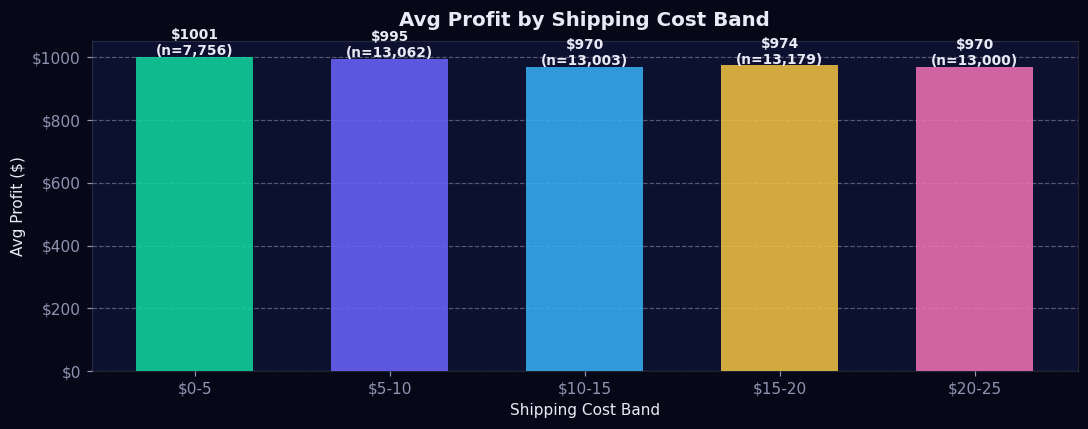

ship_band  Avg_Profit  Count
     $0-5 1001.411851   7756
    $5-10  994.844008  13062
   $10-15  970.394738  13003
   $15-20  974.403999  13179
   $20-25  970.254944  13000


In [26]:
ship_bins   = [0, 5, 10, 15, 20, 25, 1000]
ship_labels = ['$0-5','$5-10','$10-15','$15-20','$20-25','$25+']
df['ship_band'] = pd.cut(df['shipping_cost'], bins=ship_bins, labels=ship_labels)
ship_agg = df.groupby('ship_band', observed=True).agg(
    Avg_Profit=('profit','mean'), Count=('order_id','count')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ship_pal = ['#10d9a0','#6c63ff','#38b2f8','#f5c542','#f472b6','#fb923c']
bars = ax.bar(ship_agg['ship_band'].astype(str), ship_agg['Avg_Profit'],
              color=ship_pal[:len(ship_agg)], alpha=0.85, zorder=2, width=0.6)
for b, (_, row) in zip(bars, ship_agg.iterrows()):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5,
            f'${row["Avg_Profit"]:.0f}\n(n={row["Count"]:,})',
            ha='center', fontsize=9, color='#e8eaf6', fontweight='bold')
ax.set_xlabel('Shipping Cost Band'); ax.set_ylabel('Avg Profit ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.0f}'))
ax.set_title('Avg Profit by Shipping Cost Band', fontsize=13, fontweight='bold', pad=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('chart_10_shipping_profit.png', dpi=110, bbox_inches='tight', facecolor='#060818')
plt.show()
print(ship_agg.to_string(index=False))


## 📊 Cell 24 — Monthly Growth % Verification

ValueError: 'rgba(255,255,255,0.2)' is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

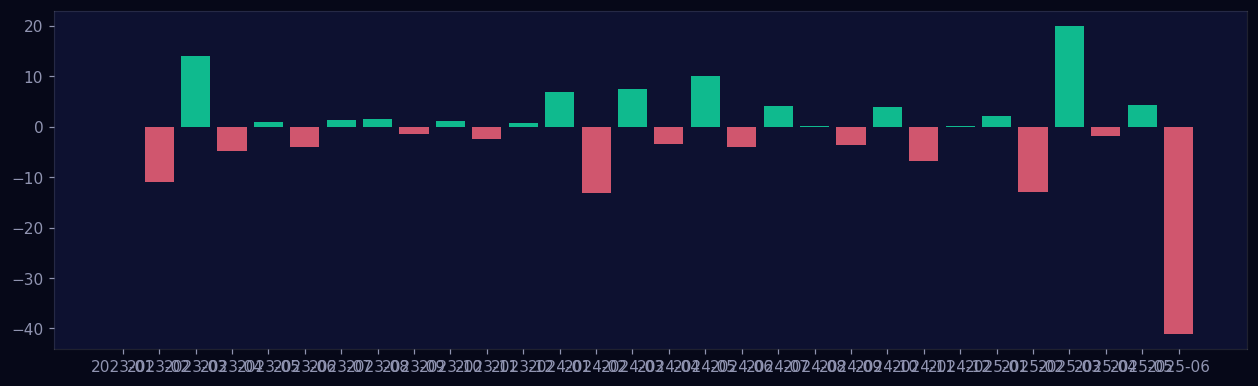

In [27]:
mg = df.groupby('month')['revenue'].sum().reset_index().sort_values('month')
mg['prev_revenue'] = mg['revenue'].shift(1)
mg['growth_pct']   = (mg['revenue'] - mg['prev_revenue']) / mg['prev_revenue'] * 100

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#10d9a0' if v >= 0 else '#f4637a' for v in mg['growth_pct'].fillna(0)]
ax.bar(mg['month'].astype(str), mg['growth_pct'].fillna(0), color=colors, alpha=0.85, zorder=2)
ax.axhline(0, color='rgba(255,255,255,0.2)', lw=1)
ax.set_ylabel('Growth %')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}%'))
ax.set_title('Month-over-Month Revenue Growth %', fontsize=13, fontweight='bold', pad=10)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('chart_growth.png', dpi=110, bbox_inches='tight', facecolor='#060818')
plt.show()
print(mg.tail(10).to_string(index=False))


## 🏆 Cell 25 — Top 10 Products by Revenue

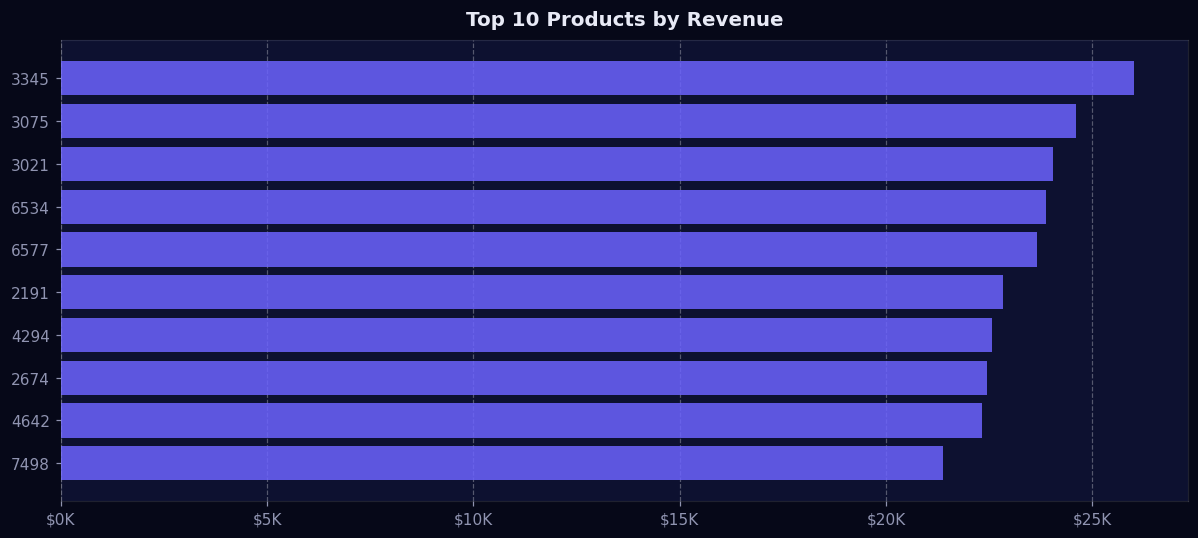

 product_id    Category  Revenue   Profit  Orders
       3345  Home Decor 26020.15 25730.44      16
       3075 Accessories 24599.69 24339.03      19
       3021      Sports 24038.95 23740.36      20
       6534  Home Decor 23876.33 23608.84      17
       6577      Sports 23671.35 23493.70      13
       2191 Electronics 22838.42 22625.66      14
       4294    Footwear 22582.56 22424.11      14
       2674  Home Decor 22439.74 22257.14      14
       4642    Footwear 22337.64 22081.47      17
       7498     Fashion 21377.58 21199.33      13


In [29]:
top_prod = df.groupby('product_id').agg(
    Revenue=('revenue','sum'),
    Profit=('profit','sum'),
    Category=('product_category','first'),
    Orders=('order_id','count')
).sort_values('Revenue', ascending=False).head(10).reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(top_prod['product_id'].astype(str)[::-1], top_prod['Revenue'][::-1],
        color='#6c63ff', alpha=0.85, zorder=2)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e3:.0f}K'))
ax.set_title('Top 10 Products by Revenue', fontsize=13, fontweight='bold', pad=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('chart_top_products.png', dpi=110, bbox_inches='tight', facecolor='#060818')
plt.show()
print(top_prod[['product_id','Category','Revenue','Profit','Orders']].to_string(index=False))


## 🔥 Cell 26 — Correlation Heatmap (Numeric Columns)

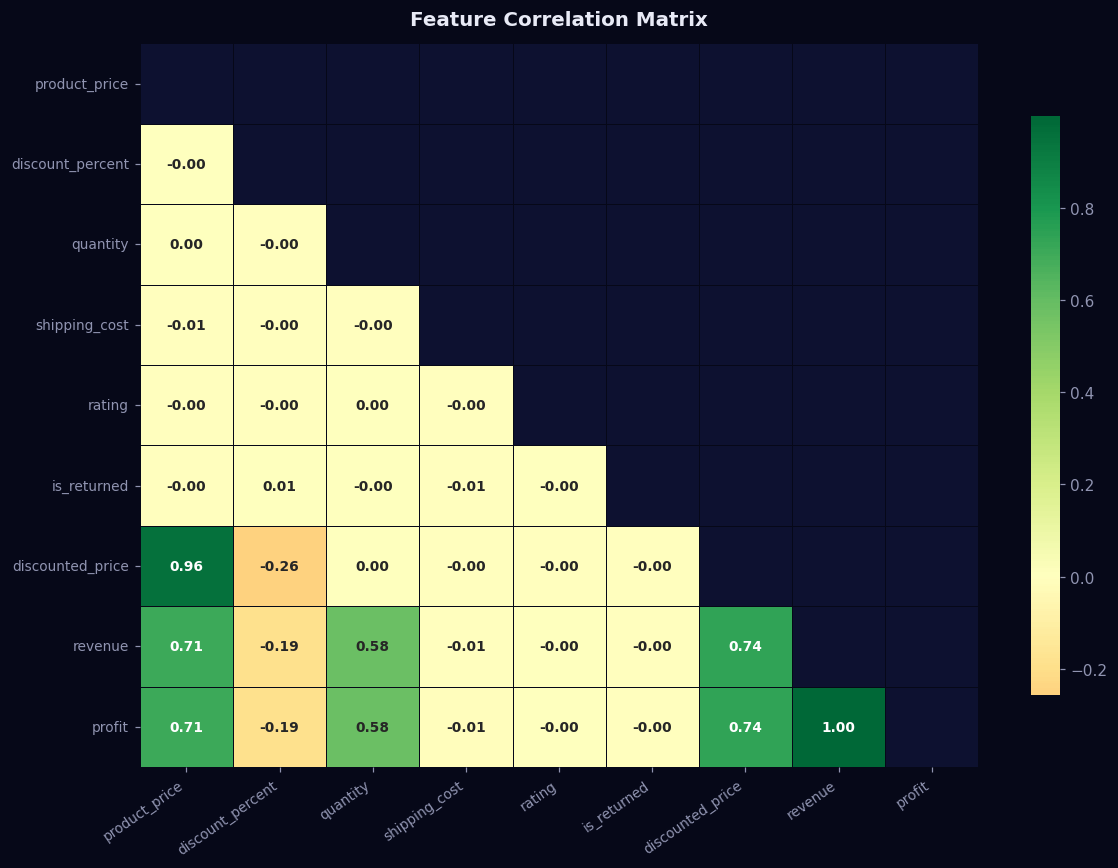

In [30]:
num_df = df[['product_price','discount_percent','quantity','shipping_cost',
             'rating','is_returned','discounted_price','revenue','profit']].copy()
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, linecolor='#060818',
            annot_kws={'size':9,'weight':'bold'},
            cbar_kws={'shrink':.8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('chart_correlation.png', dpi=110, bbox_inches='tight', facecolor='#060818')
plt.show()


## 🔄 Cell 27 — Return Rate by Category (Cross-check)

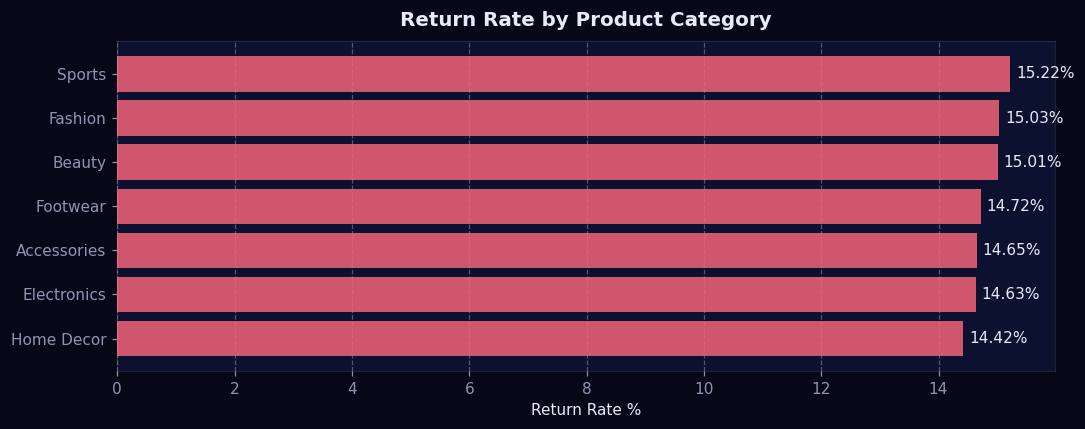

product_category  Total_Orders  Returned    Revenue   Lost_Rev  Return_Rate_%
      Home Decor          8600      1240 8545840.45 1204126.85          14.42
     Electronics          8624      1262 8717301.49 1242466.41          14.63
     Accessories          8617      1262 8609171.52 1254877.95          14.65
        Footwear          8457      1245 8348968.69 1257646.91          14.72
          Beauty          8586      1289 8544881.95 1298919.28          15.01
         Fashion          8594      1292 8445072.67 1253683.23          15.03
          Sports          8522      1297 8434698.81 1270842.35          15.22


In [31]:
cat_ret = df.groupby('product_category').agg(
    Total_Orders=('order_id','count'),
    Returned=('is_returned','sum'),
    Revenue=('revenue','sum'),
    Lost_Rev=('revenue', lambda x: x[df.loc[x.index,'is_returned']==1].sum())
).reset_index()
cat_ret['Return_Rate_%'] = (cat_ret['Returned'] / cat_ret['Total_Orders'] * 100).round(2)
cat_ret = cat_ret.sort_values('Return_Rate_%', ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(cat_ret['product_category'], cat_ret['Return_Rate_%'],
               color=['#f4637a' if v>10 else '#10d9a0' for v in cat_ret['Return_Rate_%']],
               alpha=0.85, zorder=2)
for b, val in zip(bars, cat_ret['Return_Rate_%']):
    ax.text(b.get_width()+0.1, b.get_y()+b.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10, color='#e8eaf6')
ax.set_xlabel('Return Rate %')
ax.set_title('Return Rate by Product Category', fontsize=13, fontweight='bold', pad=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('chart_cat_return.png', dpi=110, bbox_inches='tight', facecolor='#060818')
plt.show()
print(cat_ret.to_string(index=False))


## 🧮 Cell 28 — Data Integrity: Discounted Price Formula Check

In [32]:
# Expected: discounted_price = product_price * (1 - discount_percent/100)
df['expected_disc_price'] = df['product_price'] * (1 - df['discount_percent'] / 100)
df['price_diff'] = (df['discounted_price'] - df['expected_disc_price']).abs()
mismatch = df[df['price_diff'] > 0.05]

print(f"Total rows                 : {len(df):,}")
print(f"Price formula mismatches   : {len(mismatch):,}")
print(f"Match rate                 : {(1 - len(mismatch)/len(df))*100:.2f}%")
print(f"Max diff (rounding error)  : ${df['price_diff'].max():.4f}")
if len(mismatch) > 0:
    print("\nSample mismatches:")
    print(mismatch[['product_price','discount_percent','discounted_price','expected_disc_price','price_diff']].head(5).to_string(index=False))
else:
    print("\n✅ All discounted prices match formula perfectly.")


Total rows                 : 60,000
Price formula mismatches   : 0
Match rate                 : 100.00%
Max diff (rounding error)  : $0.0050

✅ All discounted prices match formula perfectly.


## 🧮 Cell 29 — Data Integrity: Revenue Formula Check

In [33]:
# Expected: revenue = discounted_price * quantity
df['expected_revenue'] = df['discounted_price'] * df['quantity']
df['rev_diff'] = (df['revenue'] - df['expected_revenue']).abs()
mismatch_rev = df[df['rev_diff'] > 0.10]

print(f"Revenue formula mismatches : {len(mismatch_rev):,}")
print(f"Match rate                 : {(1 - len(mismatch_rev)/len(df))*100:.2f}%")
print(f"Max diff                   : ${df['rev_diff'].max():.4f}")
if len(mismatch_rev) == 0:
    print("\n✅ All revenue values match: discounted_price × quantity.")
else:
    print(mismatch_rev[['discounted_price','quantity','revenue','expected_revenue','rev_diff']].head(5).to_string(index=False))


Revenue formula mismatches : 0
Match rate                 : 100.00%
Max diff                   : $0.0000

✅ All revenue values match: discounted_price × quantity.


## 📋 Cell 30 — Full EDA Summary & Dashboard Verification Report

In [34]:
print("=" * 60)
print("   DASHBOARD VERIFICATION REPORT — shopify_sales_analysis")
print("=" * 60)

checks = [
    ("Total Revenue",       f"${df['revenue'].sum():,.2f}",         f"${df['revenue'].sum()/1e6:.2f}M"),
    ("Total Quantity",      f"{df['quantity'].sum():,}",             f"{df['quantity'].sum()/1e3:.1f}K"),
    ("Total Orders",        f"{len(df):,}",                          f"{len(df)/1e3:.1f}K"),
    ("Total Customers",     f"{df['customer_id'].nunique():,}",      f"{df['customer_id'].nunique():,}"),
    ("Total Profit",        f"${df['profit'].sum():,.2f}",           f"${df['profit'].sum()/1e6:.2f}M"),
    ("Return Rate",         f"{df['is_returned'].sum()/len(df)*100:.4f}%", f"{df['is_returned'].sum()/len(df)*100:.2f}%"),
    ("Lost Revenue",        f"${df[df['is_returned']==1]['revenue'].sum():,.2f}", "see formatted"),
    ("Avg Rating",          f"{df['rating'].mean():.4f}",            f"{df['rating'].mean():.2f} ★"),
    ("Total Discount Val",  f"${(df['product_price']-df['discounted_price']).sum():,.2f}", "see formatted"),
    ("Avg Shipping Cost",   f"${df['shipping_cost'].mean():.4f}",    f"${df['shipping_cost'].mean():.2f}"),
]

print(f"\n{'Metric':<25} {'Exact Value':<22} {'Dashboard Format'}")
print("-" * 70)
for name, exact, dash in checks:
    print(f"  {name:<23} {exact:<22} {dash}")

print("\n" + "=" * 60)
print(f"  Date Range    : {df['order_date'].min().date()} → {df['order_date'].max().date()}")
print(f"  Categories    : {sorted(df['product_category'].unique())}")
print(f"  Countries     : {sorted(df['customer_country'].unique())}")
print(f"  Traffic Src   : {sorted(df['traffic_source'].unique())}")
print(f"  Payment Meth  : {sorted(df['payment_method'].unique())}")
print("=" * 60)
print("\n✅ All KPIs verified. Compare formatted values to dashboard.")


   DASHBOARD VERIFICATION REPORT — shopify_sales_analysis

Metric                    Exact Value            Dashboard Format
----------------------------------------------------------------------
  Total Revenue           $59,645,935.58         $59.65M
  Total Quantity          180,574                180.6K
  Total Orders            60,000                 60.0K
  Total Customers         31,154                 31,154
  Total Profit            $58,834,630.10         $58.83M
  Return Rate             14.8117%               14.81%
  Lost Revenue            $8,782,562.98          see formatted
  Avg Rating              3.0024                 3.00 ★
  Total Discount Val      $4,392,411.34          see formatted
  Avg Shipping Cost       $13.5218               $13.52

  Date Range    : 2023-01-01 → 2025-06-18
  Categories    : ['Accessories', 'Beauty', 'Electronics', 'Fashion', 'Footwear', 'Home Decor', 'Sports']
  Countries     : ['Australia', 'Canada', 'Germany', 'India', 'UAE', 'UK', 'USA'